<a href="https://colab.research.google.com/github/sgevatschnaider/estadisticas-para-ciencia-de-datos/blob/main/notebooks/Estad%C3%ADstica_para_ciencia_de_datos_M%C3%93DULO_I.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


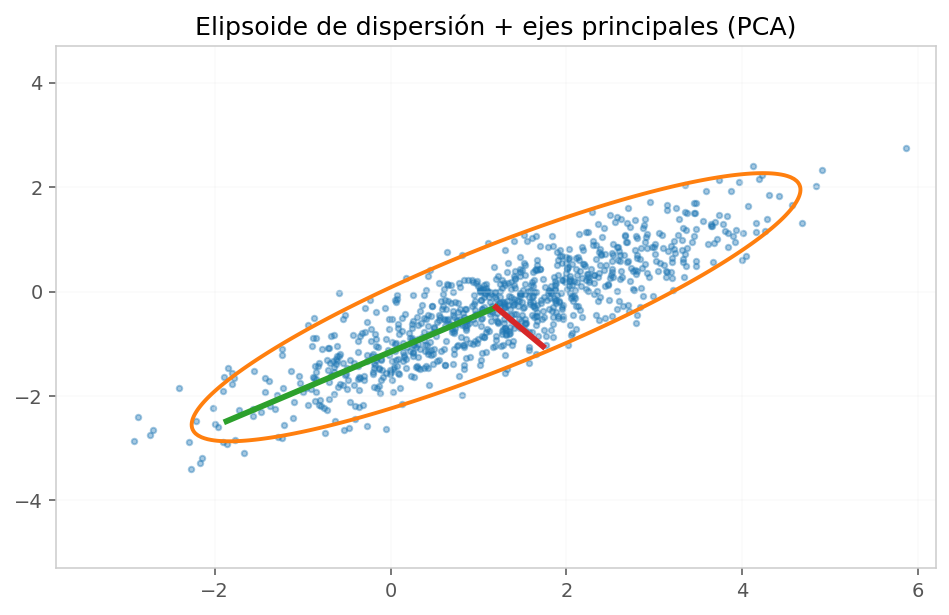
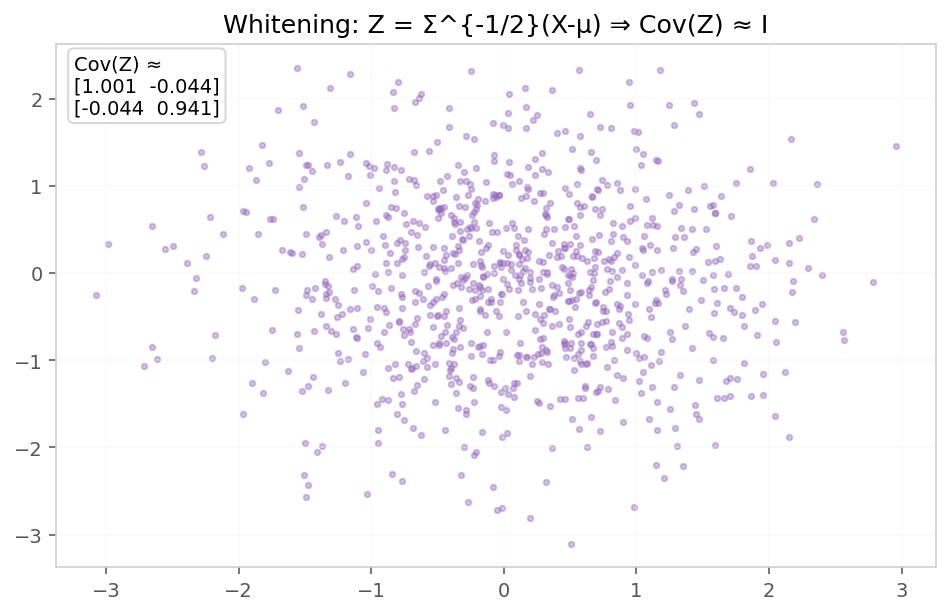
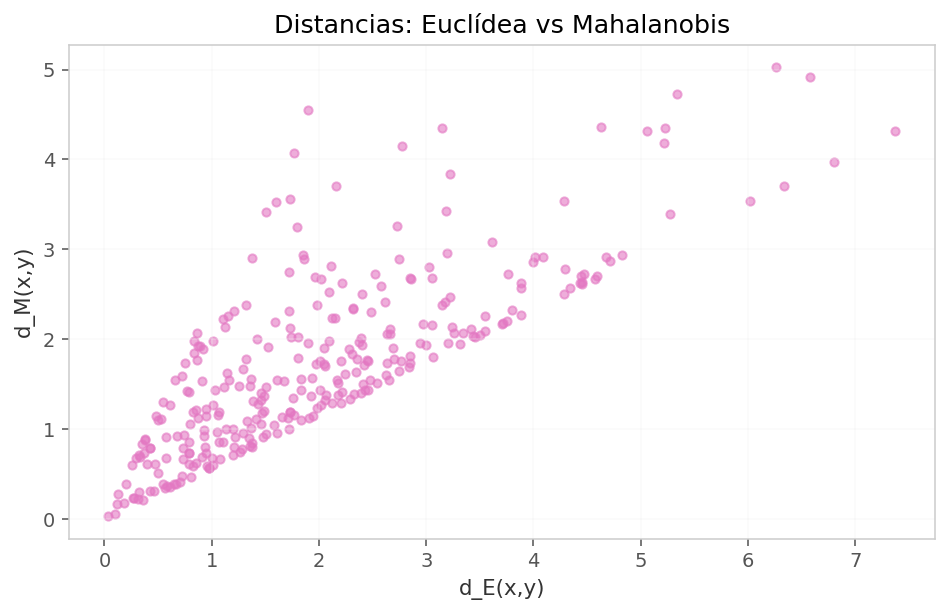
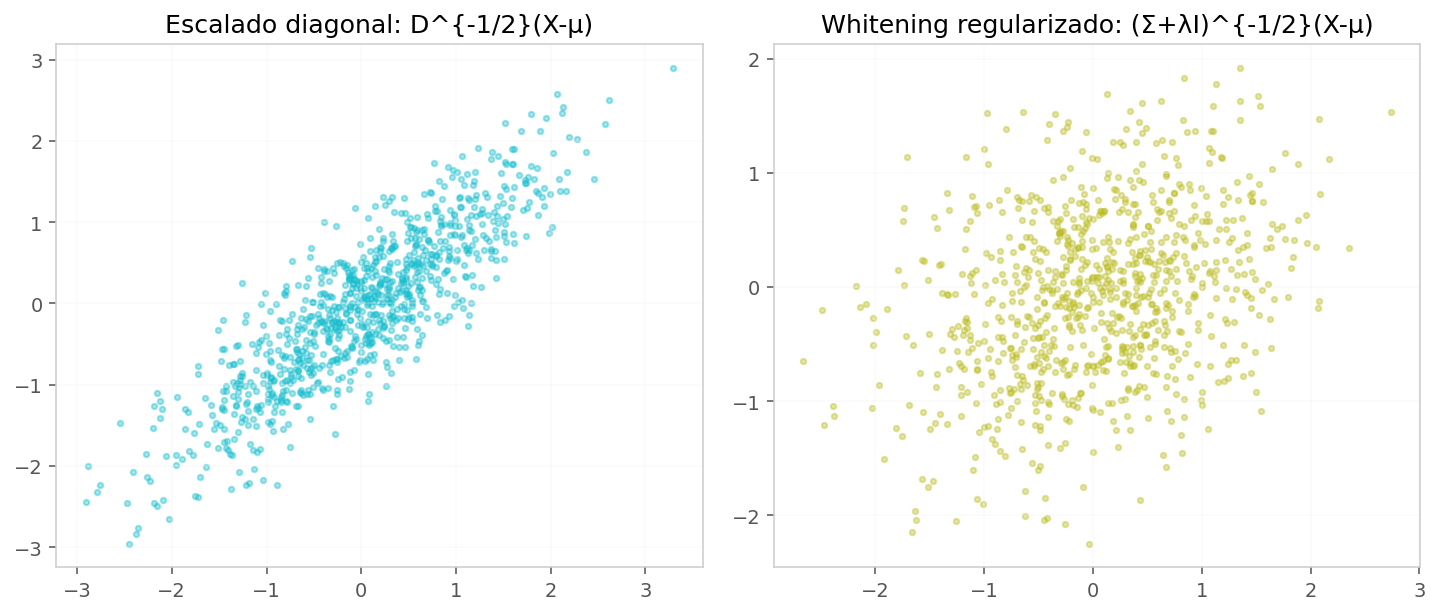
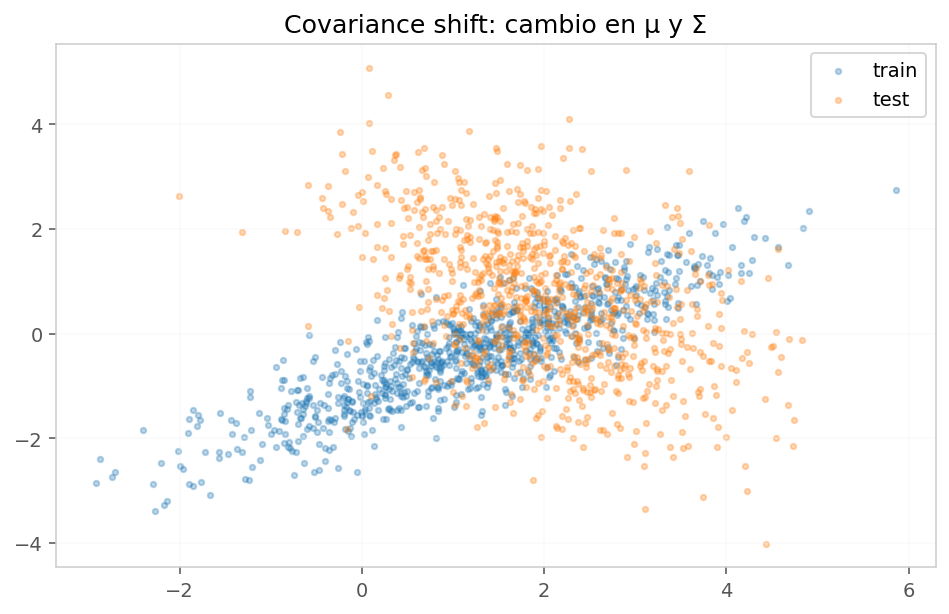
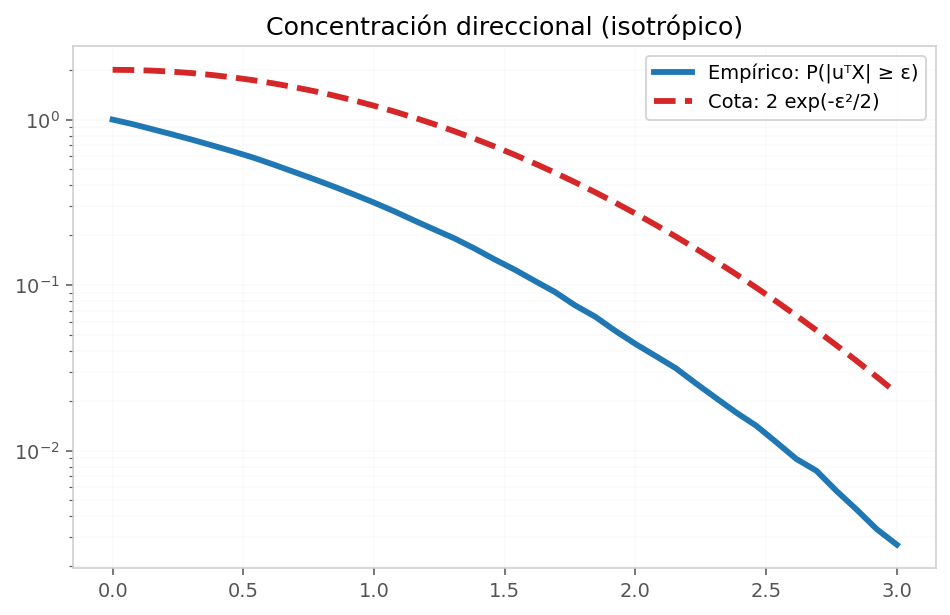

In [ ]:
# @title
# ============================================================
#  MÓDULO I / Punto 1 - Geometría de (μ, Σ)
#  (VERSIÓN CON PRESENTACIÓN INTERACTIVA MODERNA)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from io import BytesIO
import base64
from IPython.display import HTML, display
import html

# --- 1. Configuración de Estilo Matplotlib ---
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#cccccc',
    'axes.labelcolor': '#333333',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.color': '#555555',
    'ytick.color': '#555555',
    'grid.color': '#eeeeee',
    'lines.linewidth': 2,
    'font.family': 'sans-serif',
})

# --- 2. Helpers Numéricos ---
def ensure_spd(S, eps=1e-10, jitter=1e-8):
    S = 0.5 * (S + S.T)
    w, V = np.linalg.eigh(S)
    w = np.maximum(w, eps)
    S_spd = (V * w) @ V.T
    S_spd = S_spd + jitter * np.eye(S_spd.shape[0])
    return 0.5 * (S_spd + S_spd.T)

def inv_sqrtm_spd(S):
    w, V = np.linalg.eigh(S)
    w = np.maximum(w, 1e-12)
    return (V * (1.0 / np.sqrt(w))) @ V.T

def sample_gaussian(mu, Sigma, n, rng):
    return rng.multivariate_normal(mean=mu, cov=Sigma, size=n)

def pca_from_cov(Sigma):
    w, Q = np.linalg.eigh(Sigma)
    idx = np.argsort(w)[::-1]
    return w[idx], Q[:, idx]

def fig_to_base64(fig, dpi=140):
    buf = BytesIO()
    fig.tight_layout(pad=1.5)
    fig.savefig(buf, format="png", dpi=dpi, bbox_inches="tight", facecolor=fig.get_facecolor())
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

# --- 3. Generación de Todos los Gráficos (Base64) ---
def generar_todos_los_graficos():
    graficos_b64 = {}
    rng = np.random.default_rng(7)

    # Datos base
    mu = np.array([1.2, -0.3])
    Sigma_raw = np.array([[2.0, 1.3], [1.3, 1.1]])
    Sigma = ensure_spd(Sigma_raw, eps=1e-9, jitter=1e-8)
    n = 900
    X = sample_gaussian(mu, Sigma, n, rng)

    # Datos Test (Covariance Shift)
    mu_test = np.array([2.0, 0.6])
    Sigma_test_raw = np.array([[1.2, -0.7], [-0.7, 1.8]])
    Sigma_test = ensure_spd(Sigma_test_raw, eps=1e-9, jitter=1e-8)
    X_test = sample_gaussian(mu_test, Sigma_test, n, rng)

    # Figura 1: Elipsoide y PCA
    w, Q = pca_from_cov(Sigma)
    c = 5.991
    xs = np.linspace(mu[0] - 5, mu[0] + 5, 280)
    ys = np.linspace(mu[1] - 5, mu[1] + 5, 280)
    XX, YY = np.meshgrid(xs, ys)
    Z = np.zeros_like(XX)
    Sinv = np.linalg.inv(Sigma)
    for i in range(XX.shape[0]):
        d = np.stack([XX[i] - mu[0], YY[i] - mu[1]], axis=1)
        Z[i] = np.einsum("ij,jk,ik->i", d, Sinv, d)

    fig1 = plt.figure(figsize=(7.0, 4.6))
    ax1 = plt.gca()
    ax1.scatter(X[:, 0], X[:, 1], s=8, alpha=0.4, color='#1f77b4')
    ax1.contour(XX, YY, Z, levels=[c], linewidths=2, colors=['#ff7f0e'])
    scale = np.sqrt(w)
    colors_pca = ['#2ca02c', '#d62728']
    for j in range(2):
        v = Q[:, j]
        ax1.plot([mu[0], mu[0] + 2.2 * scale[j] * v[0]], [mu[1], mu[1] + 2.2 * scale[j] * v[1]], linewidth=3, color=colors_pca[j])
    ax1.set_title("Elipsoide de dispersión + ejes principales (PCA)")
    ax1.grid(True, alpha=0.3)
    graficos_b64['fig1'] = fig_to_base64(fig1)

    # Figura 2: Whitening
    W = inv_sqrtm_spd(Sigma)
    Z_whitened = (X - mu) @ W.T
    covZ = np.cov(Z_whitened.T)
    fig2 = plt.figure(figsize=(7.0, 4.6))
    ax2 = plt.gca()
    ax2.scatter(Z_whitened[:, 0], Z_whitened[:, 1], s=8, alpha=0.4, color='#9467bd')
    ax2.set_title("Whitening: Z = Σ^{-1/2}(X-μ) ⇒ Cov(Z) ≈ I")
    ax2.grid(True, alpha=0.3)
    txt = f"Cov(Z) ≈\n[{covZ[0,0]:.3f}  {covZ[0,1]:.3f}]\n[{covZ[1,0]:.3f}  {covZ[1,1]:.3f}]"
    ax2.text(0.02, 0.98, txt, transform=ax2.transAxes, va="top", bbox=dict(boxstyle="round", facecolor='white', alpha=0.8, edgecolor='#cccccc'))
    graficos_b64['fig2'] = fig_to_base64(fig2)

    # Figura 3: Mahalanobis
    idx = rng.choice(len(X), size=2 * 300, replace=False)
    A = X[idx[:300]]; B = X[idx[300:]]
    dE = np.linalg.norm(A - B, axis=1)
    diff = A - B
    dM2 = np.einsum("ij,jk,ik->i", diff, Sinv, diff)
    dM = np.sqrt(np.maximum(dM2, 0.0))
    fig3 = plt.figure(figsize=(7.0, 4.6))
    ax3 = plt.gca()
    ax3.scatter(dE, dM, s=18, alpha=0.6, color='#e377c2')
    ax3.set_title("Distancias: Euclídea vs Mahalanobis")
    ax3.set_xlabel("d_E(x,y)"); ax3.set_ylabel("d_M(x,y)"); ax3.grid(True, alpha=0.3)
    graficos_b64['fig3'] = fig_to_base64(fig3)

    # Figura 4: Feature Scaling vs Whitening Regularizado
    D = np.diag(np.diag(Sigma))
    D = ensure_spd(D, eps=1e-9, jitter=1e-8)
    Wd = inv_sqrtm_spd(D)
    Zd = (X - mu) @ Wd.T
    lam = 0.25
    Sreg = ensure_spd(Sigma + lam * np.eye(2), eps=1e-9, jitter=1e-8)
    Wr = inv_sqrtm_spd(Sreg)
    Zr = (X - mu) @ Wr.T
    fig4 = plt.figure(figsize=(10.5, 4.6))
    ax4a = plt.subplot(1, 2, 1)
    ax4a.scatter(Zd[:, 0], Zd[:, 1], s=8, alpha=0.4, color='#17becf')
    ax4a.set_title("Escalado diagonal: D^{-1/2}(X-μ)")
    ax4a.grid(True, alpha=0.3)
    ax4b = plt.subplot(1, 2, 2)
    ax4b.scatter(Zr[:, 0], Zr[:, 1], s=8, alpha=0.4, color='#bcbd22')
    ax4b.set_title("Whitening regularizado: (Σ+λI)^{-1/2}(X-μ)")
    ax4b.grid(True, alpha=0.3)
    graficos_b64['fig4'] = fig_to_base64(fig4)

    # Figura 5: Covariance Shift
    fig5 = plt.figure(figsize=(7.0, 4.6))
    ax5 = plt.gca()
    ax5.scatter(X[:, 0], X[:, 1], s=8, alpha=0.3, label="train", color='#1f77b4')
    ax5.scatter(X_test[:, 0], X_test[:, 1], s=8, alpha=0.3, label="test", color='#ff7f0e')
    ax5.set_title("Covariance shift: cambio en μ y Σ")
    ax5.grid(True, alpha=0.3); ax5.legend()
    graficos_b64['fig5'] = fig_to_base64(fig5)

    # Figura 6: Concentración
    p = 30
    u = rng.normal(size=p)
    u = u / np.linalg.norm(u)
    X0 = rng.normal(size=(20000, p))
    proj = X0 @ u
    eps_grid = np.linspace(0.0, 3.0, 40)
    emp = np.array([np.mean(np.abs(proj) >= e) for e in eps_grid])
    bound = 2.0 * np.exp(-(eps_grid ** 2) / 2.0)
    fig6 = plt.figure(figsize=(7.0, 4.6))
    ax6 = plt.gca()
    ax6.plot(eps_grid, emp, linewidth=3, label="Empírico: P(|uᵀX| ≥ ε)", color='#1f77b4')
    ax6.plot(eps_grid, bound, linewidth=3, linestyle='--', label="Cota: 2 exp(-ε²/2)", color='#d62728')
    ax6.set_yscale("log")
    ax6.set_title("Concentración direccional (isotrópico)")
    ax6.grid(True, alpha=0.3, which='both'); ax6.legend()
    graficos_b64['fig6'] = fig_to_base64(fig6)

    return graficos_b64

# Generamos las imágenes antes de inyectarlas
graficos = generar_todos_los_graficos()

# --- 4. Contenido Dinámico para Acordeón ---
datos_geometria = [
    {
        "titulo": "1. Propiedades Estructurales y Lectura Direccional",
        "contenido": f"""
            <p>Sea $X\\in\\mathbb{{R}}^p$ un vector aleatorio con segundo momento finito. La descripción de primer y segundo orden queda codificada por el vector de medias $\\mu = \\mathbb{{E}}[X] \\in \\mathbb{{R}}^p$ y la matriz de covarianza $\\Sigma = \\mathbb{{E}}[(X-\\mu)(X-\\mu)^\\top] \\in \\mathbb{{R}}^{{p\\times p}}$.</p>
            <p>Tal como lo establecen textos canónicos de análisis multivariante, esta notación matricial no es un mero artificio algebraico, sino que revela la geometría fundamental. Para cualquier dirección dada por un vector unitario $u \\in \\mathbb{{R}}^p$, la varianza de la proyección se extrae a través de la forma cuadrática:</p>
            <div class="formula-block">$$u^\\top\\Sigma u = \\mathbb{{E}}\\big[(u^\\top(X-\\mu))^2\\big] = \\mathrm{{Var}}(u^\\top X) \\ge 0$$</div>
            <p>Apoyándonos en el <b>Teorema Espectral</b>, toda matriz real simétrica admite una diagonalización ortogonal: $\\Sigma = Q\\Lambda Q^\\top = \\sum_{{j=1}}^p \\lambda_j q_j q_j^\\top$. Aquí, las columnas de $Q$ representan un nuevo sistema de coordenadas rotado (direcciones principales).</p>
            <div style="padding:15px; background: rgba(255,255,255,0.03); border-radius: 10px; margin-top: 20px;">
                <img src="data:image/png;base64,{graficos['fig1']}" alt="Elipsoide de dispersión" style="width:100%; max-width:650px; display:block; margin:auto; border-radius: 10px;">
                <p style="text-align:center; font-size:0.9em; margin-top:10px; opacity:0.8;">Figura 1 — Elipsoide de dispersión y ejes principales dictados por autovectores.</p>
            </div>
        """
    },
    {
        "titulo": "2. Elipsoides de Dispersión y Blanqueo (Whitening)",
        "contenido": f"""
            <p>Para distribuciones con $\\Sigma \\succ 0$, su inversa $\\Sigma^{{-1}}$ (la matriz de precisión) está bien definida. Los contornos de densidad constante forman hiperelipsoides definidos por:</p>
            <div class="formula-block">$$E(c) = \\{{x \\in \\mathbb{{R}}^p : (x-\\mu)^\\top\\Sigma^{{-1}}(x-\\mu) \\le c\\}}$$</div>
            <p>El <b>blanqueo (whitening)</b> es una transformación lineal $Z = W(X-\\mu)$ tal que $\\mathbb{{E}}[Z]=0$ y $\\mathrm{{Cov}}(Z)=I$. Esto ocurre si y solo si $W^\\top W = \\Sigma^{{-1}}$. Geométricamente, el blanqueo distorsiona el espacio para convertir los elipsoides en esferas perfectas.</p>
            <div style="padding:15px; background: rgba(255,255,255,0.03); border-radius: 10px; margin-top: 20px;">
                <img src="data:image/png;base64,{graficos['fig2']}" alt="Whitening" style="width:100%; max-width:650px; display:block; margin:auto; border-radius: 10px;">
                <p style="text-align:center; font-size:0.9em; margin-top:10px; opacity:0.8;">Figura 2 — Espacio blanqueado: La covarianza se convierte en la matriz identidad.</p>
            </div>
        """
    },
    {
        "titulo": "3. Transformaciones Lineales y Criterio Variacional de PCA",
        "contenido": f"""
            <p>La ley fundamental de la propagación de covarianzas establece que, para cualquier transformación afín $Y = AX + b$ (donde $A \\in \\mathbb{{R}}^{{k \\times p}}$), los momentos se transforman como:</p>
            <div class="formula-block">$$\\mathbb{{E}}[Y] = A\\mu + b, \\qquad \\mathrm{{Cov}}(Y) = A\\Sigma A^\\top$$</div>
            <p>El <b>Análisis de Componentes Principales (PCA)</b> es la solución a un problema estricto de optimización. Sea $S$ un subespacio de dimensión $k$ y $P_S$ la matriz de proyección ortogonal sobre $S$. La varianza total retenida en esa proyección es:</p>
            <div class="formula-block">$$\\mathrm{{Var}}(P_S X) = \\mathrm{{tr}}(P_S\\Sigma)$$</div>
            <blockquote>El Teorema de Courant-Fischer demuestra que maximizar esta traza nos lleva ineludiblemente al subespacio expandido por los $k$ autovectores dominantes de $\\Sigma$.</blockquote>
        """
    },
    {
        "titulo": "4. Métrica Inducida y Distancia de Mahalanobis",
        "contenido": f"""
            <p>La métrica Euclídea ordinaria es "ciega" a la distribución de los datos. La matriz de covarianza induce una geometría intrínseca a través del producto interno $\\langle a,b\\rangle_{{\\Sigma^{{-1}}}} = a^\\top\\Sigma^{{-1}}b$. La distancia inducida es la <b>Distancia de Mahalanobis</b>:</p>
            <div class="formula-block">$$d_M(x,y) = \\sqrt{{(x-y)^\\top\\Sigma^{{-1}}(x-y)}}$$</div>
            <p>Una de las equivalencias más elegantes del álgebra estadística es que la distancia Euclídea en un espacio previamente "blanqueado" es exactamente la distancia de Mahalanobis en el original:</p>
            <div class="formula-block">$$\\|\\tilde{{x}}-\\tilde{{y}}\\|_2^2 = (x-y)^\\top W^\\top W (x-y) = (x-y)^\\top\\Sigma^{{-1}}(x-y) = d_M(x,y)^2$$</div>
            <div style="padding:15px; background: rgba(255,255,255,0.03); border-radius: 10px; margin-top: 20px;">
                <img src="data:image/png;base64,{graficos['fig3']}" alt="Mahalanobis vs Euclidea" style="width:100%; max-width:650px; display:block; margin:auto; border-radius: 10px;">
            </div>
        """
    },
    {
        "titulo": "5. Regularización y Covariance Shift",
        "contenido": f"""
            <p>En Machine Learning de alta dimensión, la covarianza muestral $\\hat{{\\Sigma}}$ se vuelve inestable, impidiendo calcular $\\Sigma^{{-1}}$. La solución moderna es aplicar <b>Shrinkage (Ridge)</b>: $\\Sigma_\\lambda = \\Sigma + \\lambda I$.</p>
            <div style="padding:15px; background: rgba(255,255,255,0.03); border-radius: 10px; margin-top: 10px; margin-bottom: 20px;">
                <img src="data:image/png;base64,{graficos['fig4']}" alt="Feature Scaling" style="width:100%; max-width:850px; display:block; margin:auto; border-radius: 10px;">
            </div>
            <p>Por otro lado, el <b>Covariance Shift</b> ocurre cuando la distribución marginal cambia entre Train y Test ($P_{{train}}(X) \\neq P_{{test}}(X)$). Podemos medir este cambio con la <b>Divergencia de Kullback-Leibler</b>:</p>
            <div class="formula-block" style="font-size:0.9em;">$$D_{{KL}}(\\mathcal{{N}}_0 || \\mathcal{{N}}_1) = \\frac{{1}}{{2}} \\left( \\mathrm{{tr}}(\\Sigma_1^{{-1}}\\Sigma_0) + (\\mu_1-\\mu_0)^\\top \\Sigma_1^{{-1}} (\\mu_1-\\mu_0) - p + \\ln\\left(\\frac{{|\\Sigma_1|}}{{|\\Sigma_0|}}\\right) \\right)$$</div>
            <div style="padding:15px; background: rgba(255,255,255,0.03); border-radius: 10px; margin-top: 10px;">
                <img src="data:image/png;base64,{graficos['fig5']}" alt="Covariance Shift" style="width:100%; max-width:650px; display:block; margin:auto; border-radius: 10px;">
            </div>
        """
    },
    {
        "titulo": "6. Concentración Direccional (Maldición de la Dimensión)",
        "contenido": f"""
            <p>A medida que la dimensión $p$ aumenta, casi todo el volumen de una Gaussiana se concentra en una "cáscara esférica" (thin shell) muy delgada a distancia $\\sqrt{{p}}$ del origen. Sin embargo, las proyecciones unidimensionales siguen comportándose dócilmente. Por la desigualdad de Hoeffding/Chernoff, la cola cae de forma subgaussiana:</p>
            <div class="formula-block">$$\\mathbb{{P}}(|u^\\top(X-\\mu)| \\ge \\varepsilon) \\le 2\\exp\\left(-\\frac{{\\varepsilon^2}}{{2\\,u^\\top\\Sigma u}}\\right), \\quad \\|u\\|_2=1$$</div>
            <div style="padding:15px; background: rgba(255,255,255,0.03); border-radius: 10px; margin-top: 20px;">
                <img src="data:image/png;base64,{graficos['fig6']}" alt="Concentracion Direccional" style="width:100%; max-width:650px; display:block; margin:auto; border-radius: 10px;">
            </div>
        """
    }
]

def generar_tarjetas_acordeon(datos):
    html_generado = []
    for seccion in datos:
        titulo_escapado = html.escape(seccion['titulo'])
        contenido_html = seccion['contenido']
        plantilla_seccion = f"""
        <div class="topic-card">
            <div class="topic-header">
                <span class="topic-title">{titulo_escapado}</span>
                <i class="fas fa-chevron-down expand-icon"></i>
            </div>
            <div class="topic-content">
                {contenido_html}
            </div>
        </div>
        """
        html_generado.append(plantilla_seccion)
    return "\n".join(html_generado)

contenido_dinamico_html = generar_tarjetas_acordeon(datos_geometria)

# --- 5. Bloque de Conclusión ---
conclusion_covarianza_html = f"""
<div class="content-block" style="border-left: 5px solid var(--accent-primary);">
    <h2 style="color: var(--accent-primary);">Key Concept: La Naturaleza de la Matriz Σ</h2>
    <p>La matriz de covarianza $\\Sigma$ no es un simple repositorio de estadísticos sumarios. Matemáticamente, actúa como un <b>tensor métrico y operador de forma</b>:</p>
    <ul>
        <li>Controla la dispersión en todas las proyecciones posibles ($u^\\top X$).</li>
        <li>Define una topología elipsoidal para la distribución subyacente.</li>
        <li>Proporciona el puente natural para pasar de la distancia Euclídea ordinaria a métricas estadísticamente significativas (Mahalanobis).</li>
    </ul>
    <blockquote>Es la piedra roseta que une la estadística multivariada, el álgebra lineal y el aprendizaje automático geométrico.</blockquote>
</div>
"""

# --- 6. Plantilla Base HTML/CSS/JS ---
plantilla_profesional = """
<!DOCTYPE html>
<html lang="es">
<head>
  <meta charset="UTF-8">
  <meta name="viewport" content="width=device-width, initial-scale=1.0">
  <title>{main_title}</title>
  <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&family=JetBrains+Mono:wght@400;500&display=swap" rel="stylesheet">
  <link href="https://cdnjs.cloudflare.com/ajax/libs/font-awesome/6.4.0/css/all.min.css" rel="stylesheet">
  <script>
    window.MathJax = {{ tex: {{ inlineMath: [['$', '$'], ['\\\\(', '\\\\)']], displayMath: [['$$', '$$'], ['\\\\[', '\\\\]']] }}, svg: {{ fontCache: 'global' }} }};
  </script>
  <script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js" id="MathJax-script" async></script>
  <style>
    :root {{
      --bg-primary: linear-gradient(135deg, #2c3e50 0%, #3498db 100%);
      --bg-secondary: rgba(255, 255, 255, 0.9);
      --bg-tertiary: rgba(248, 250, 252, 0.85);
      --text-primary: #2c3e50;
      --text-secondary: #34495e;
      --accent-primary: #2980b9;
      --accent-secondary: #8e44ad;
      --accent-gradient: linear-gradient(135deg, var(--accent-primary) 0%, var(--accent-secondary) 100%);
      --border-color: rgba(226, 232, 240, 0.9);
      --shadow-card: 0 15px 35px rgba(0, 0, 0, 0.08);
      --border-radius: 16px;
      --transition: all 0.4s cubic-bezier(0.25, 0.8, 0.25, 1);
    }}
    [data-theme="dark"] {{
      --bg-primary: linear-gradient(135deg, #0f2027 0%, #203a43 50%, #2c5364 100%);
      --bg-secondary: rgba(26, 32, 44, 0.85);
      --bg-tertiary: rgba(45, 55, 72, 0.7);
      --text-primary: #f7fafc;
      --text-secondary: #a0aec0;
      --accent-primary: #48dbfb;
      --accent-secondary: #1dd1a1;
      --accent-gradient: linear-gradient(135deg, #48dbfb 0%, #1dd1a1 100%);
      --border-color: rgba(255, 255, 255, 0.15);
    }}
    * {{ margin: 0; padding: 0; box-sizing: border-box; }}
    html {{ scroll-behavior: smooth; }}
    body {{ font-family: 'Inter', sans-serif; line-height: 1.8; background: var(--bg-primary); color: var(--text-primary); transition: var(--transition); min-height: 100vh; position: relative; overflow-x: hidden; }}
    .particles {{ position: fixed; top: 0; left: 0; width: 100%; height: 100%; pointer-events: none; z-index: -1; }}
    .particle {{ position: absolute; border-radius: 50%; animation: float 25s infinite linear; opacity: 0; background: rgba(255, 255, 255, 0.6);}}
    @keyframes float {{ 0% {{ transform: translateY(100vh) rotate(0deg); opacity: 0; }} 10%, 90% {{ opacity: 0.6; }} 100% {{ transform: translateY(-10vh) rotate(360deg); opacity: 0; }} }}
    .container {{ max-width: 1000px; margin: 0 auto; padding: 2rem; z-index: 1; }}
    .header {{ text-align: center; margin-bottom: 3rem; position: relative; }}
    .main-title {{ font-size: clamp(2.2rem, 4vw, 3.5rem); font-weight: 800; background: var(--accent-gradient); -webkit-background-clip: text; -webkit-text-fill-color: transparent; background-clip: text; margin-bottom: 1rem; }}
    .theme-toggle {{ position: fixed; top: 2rem; right: 2rem; width: 60px; height: 60px; border: 1px solid var(--border-color); border-radius: 50%; background: var(--bg-secondary); backdrop-filter: blur(15px); box-shadow: var(--shadow-card); cursor: pointer; display: flex; align-items: center; justify-content: center; font-size: 1.4rem; color: var(--accent-primary); transition: var(--transition); z-index: 1000; }}
    .theme-toggle:hover {{ transform: scale(1.15) rotate(180deg); }}
    .content-block {{ background: var(--bg-secondary); backdrop-filter: blur(20px); border-radius: var(--border-radius); box-shadow: var(--shadow-card); border: 1px solid var(--border-color); padding: 2.5rem; margin-top: 2rem; }}
    .content-block h2 {{ color: var(--text-primary); margin-bottom: 1rem; }}
    .content-block p, .content-block li {{ color: var(--text-secondary); }}
    .content-block ul {{ padding-left: 25px; margin-top: 15px; }}
    .lesson-container {{ display: flex; flex-direction: column; gap: 1.5rem; }}
    .topic-card {{ background: var(--bg-secondary); backdrop-filter: blur(20px); border-radius: var(--border-radius); box-shadow: var(--shadow-card); border: 1px solid var(--border-color); overflow: hidden; transition: var(--transition); }}
    .topic-header {{ cursor: pointer; padding: 1.5rem 2rem; display: flex; justify-content: space-between; align-items: center; }}
    .topic-title {{ font-size: 1.3rem; font-weight: 600; color: var(--text-primary); }}
    .expand-icon {{ font-size: 1.2rem; color: var(--text-secondary); transition: var(--transition); }}
    .topic-card.open .expand-icon {{ transform: rotate(180deg); }}
    .topic-content {{ max-height: 0; overflow: hidden; transition: max-height 1.2s ease, padding 1.2s ease; background: var(--bg-tertiary); }}
    .topic-card.open .topic-content {{ max-height: 4000px; padding: 2rem; border-top: 1px solid var(--border-color); }}
    .topic-content h4 {{ color: var(--text-primary); margin-top: 1.5rem; margin-bottom: 0.5rem; font-size: 1.1rem; }}
    .topic-content p, .topic-content li {{ color: var(--text-secondary); line-height: 1.7; margin-bottom: 15px; }}
    .topic-content ul {{ padding-left: 25px; margin-bottom: 1rem; }}
    .topic-content code {{ background: rgba(127, 140, 141, 0.1); padding: 2px 6px; border-radius: 4px; font-family: 'JetBrains Mono', monospace; }}
    .topic-content blockquote {{ border-left: 4px solid var(--accent-primary); padding-left: 1.5rem; margin: 1.5rem 0; font-style: italic; color: var(--text-secondary); background: rgba(127, 140, 141, 0.05); border-radius: 0 8px 8px 0; padding: 1rem 1.5rem; }}
    .formula-block {{ padding: 1.5rem; background: rgba(44, 62, 80, 0.15); border-radius: 10px; text-align: center; overflow-x: auto; margin: 1.5rem 0; border: 1px solid var(--border-color); font-size: 1.1em; }}
    footer {{ text-align: center; margin-top: 4rem; padding-top: 2rem; border-top: 1px solid rgba(255,255,255,0.2); }}
    footer p {{ color: rgba(255,255,255,0.8); font-size: 0.95rem; font-style: italic; }}
    @media (max-width: 768px) {{ .container {{ padding: 1rem; }} .topic-header {{ padding: 1rem 1.5rem; }} .topic-card.open .topic-content {{ padding: 1rem 1.5rem; }} .formula-block {{ padding: 1rem; }} }}
  </style>
</head>
<body data-theme="dark">
  <div class="particles" id="particles-container"></div>
  <div class="theme-toggle" id="themeToggleButton" title="Cambiar tema"><i class="fas fa-moon" id="theme-icon"></i></div>
  <div class="container">
    <header class="header">
      <h1 class="main-title">{main_title}</h1>
    </header>
    <div class="lesson-container">
        {dynamic_content_html}
    </div>
    {conclusion_html}
    <footer>
      <p>{footer_text}</p>
    </footer>
  </div>
  <script>
    (function() {{
        const themeToggleButton = document.getElementById('themeToggleButton');
        const themeIcon = document.getElementById('theme-icon');
        const bodyEl = document.body;
        function setTheme(theme) {{
            bodyEl.setAttribute('data-theme', theme);
            localStorage.setItem('theme', theme);
            if (themeIcon) {{ themeIcon.className = theme === 'dark' ? 'fas fa-sun' : 'fas fa-moon'; }}
        }}
        themeToggleButton.addEventListener('click', () => {{
            const newTheme = (bodyEl.getAttribute('data-theme') || 'dark') === 'dark' ? 'light' : 'dark';
            setTheme(newTheme);
        }});
        setTheme(localStorage.getItem('theme') || 'dark');

        document.querySelectorAll('.topic-header').forEach(header => {{
            header.addEventListener('click', () => {{
                const card = header.parentElement;
                card.classList.toggle('open');
                if (window.MathJax) {{ window.MathJax.typesetPromise([card]); }}
            }});
        }});

        const container = document.getElementById('particles-container');
        if (container) {{
            for (let i = 0; i < 30; i++) {{
                const p = document.createElement('div');
                p.className = 'particle';
                p.style.left = Math.random() * 100 + 'vw';
                const size = (Math.random() * 5 + 2);
                p.style.width = size + 'px';
                p.style.height = size + 'px';
                p.style.animationDelay = Math.random() * -20 + 's';
                p.style.animationDuration = (15 + Math.random() * 10) + 's';
                container.appendChild(p);
            }}
        }}

        const firstTopic = document.querySelector('.topic-card');
        if(firstTopic) {{
            firstTopic.classList.add('open');
            if (window.MathJax) {{ window.MathJax.typesetPromise([firstTopic]); }}
        }}
    }})();
  </script>
</body>
</html>
"""

# --- 7. Inyección y Renderizado Final ---
final_html_covarianza = plantilla_profesional.format(
    main_title="MÓDULO I: Notación Matricial y Geometría de (μ, Σ)",
    dynamic_content_html=contenido_dinamico_html,
    conclusion_html=conclusion_covarianza_html,
    footer_text="Material elaborado por el profesor Sergio Gevatschnaider"
)

display(HTML(final_html_covarianza))